# Academic Performance Analysis - Exploratory Data Analysis (EDA)
This notebook acts as the experimental environment to load, sanitize, enrich, and visualize the university's academic history dataset. All core logic is modularized inside the `src` package.

In [1]:
import os
import sys

# Navigate to the root directory to enable imports from src/ and config/
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

print(f"Current root workspace attached: {module_path}")

Current root workspace attached: c:\Users\yakin\OneDrive\Escritorio\Tesis\academic_performance_analysis


In [2]:
import pandas as pd
from src.data_cleaner import sanitize_grade_history
from src.db_connector import fetch_raw_grade_history
from src.eda_visualizer import plot_attendance_vs_grades, plot_grade_distribution
from src.feature_engineer import (
    apply_graduation_labels,
    build_progress_snapshots,
    enrich_academic_dimensions,
)

## 1. Data Extraction & Sanitization Pipeline
We extract the data directly from the PostgreSQL instance and immediately handle the invalid database entries (converting `-10` tokens into proper `NaN` values).

In [3]:
# 1. Extract raw database records
raw_grade_history = fetch_raw_grade_history()

# 2. Sanitize and replace database placeholders (-10) with NaN
cleaned_grade_history = sanitize_grade_history(raw_grade_history)

# Preview the data structure
print(f"\nCleaned dataset shape: {cleaned_grade_history.shape}")
cleaned_grade_history.head()

Executing database extraction query...
Successfully extracted 133882 raw records.
Sanitizing data records...
Data sanitization step complete.

Cleaned dataset shape: (133882, 19)


,matricula,id_carrera,id_grupo,id_materia,semestre,periodo,p1,p2,p3,o,pf,e1,e2,esp,a1,a2,a3,oa,pa
0,2024020012,2,2975,13710,2,61,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,100.0,NaN,NaN,NaN,25.0
1,2024020158,2,2975,13710,2,61,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,100.0,NaN,NaN,NaN,25.0
2,2024020204,2,2975,13710,2,61,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,90.0,NaN,NaN,NaN,22.0
3,2024020397,2,2975,13710,2,61,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,95.0,NaN,NaN,NaN,23.0
4,2024020159,2,2975,13710,2,61,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,100.0,NaN,NaN,NaN,25.0


## 2. Feature Enrichment & Labeling
We generate secure student-major hashes, map chronological periods, and assign target classification labels (`successful_graduation`) based on whether a student managed to cross into the 10th semester threshold.

In [4]:
# 1. Generate academic timeline tokens and anonymized hashes
enriched_grade_history = enrich_academic_dimensions(cleaned_grade_history)

# 2. Apply graduation target labels (1 = Graduated, 0 = Dropout)
labeled_grade_history = apply_graduation_labels(enriched_grade_history)

print("\nValue counts for Successful Graduation (Student-Major Level rows):")
print(labeled_grade_history["resultado_final"].value_counts())

Enriching dataset with academic time horizons...
Computing student retention targets (Graduated vs. Dropout)...

Value counts for Successful Graduation (Student-Major Level rows):
resultado_final
1    78406
0    55476
Name: count, dtype: int64


## 3. Data Visualizations (Exploratory Data Analysis)
### 3.1 Univariate Analysis: Final Grade Distributions by Major
We evaluate the density and shape of final grades across different academic careers.

Rendering grade distributions...


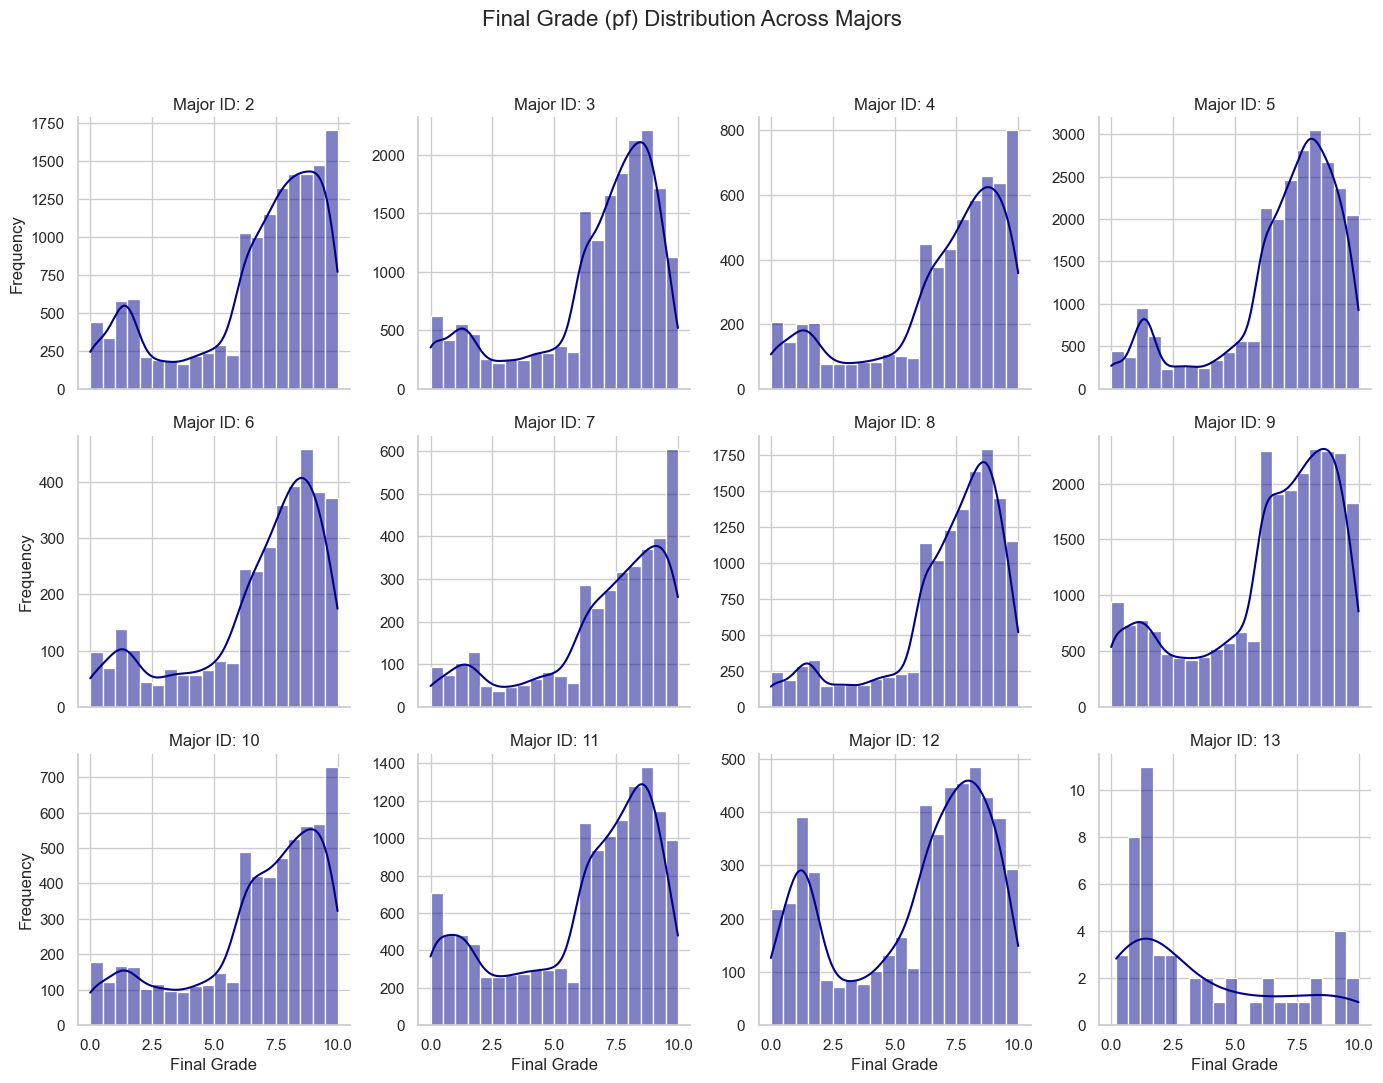

In [5]:
# Triggers the multi-plot grid for grade distributions across majors
plot_grade_distribution(labeled_grade_history)

### 3.2 Bivariate Analysis: Aggregated Attendance vs. Grades
To avoid visual overplotting, this chart compresses the rows into unique student averages, applying transparency layers and linear trend-lines to show the clear relationship between classroom attendance and academic performance.

Aggregating student levels and rendering scatter distributions...


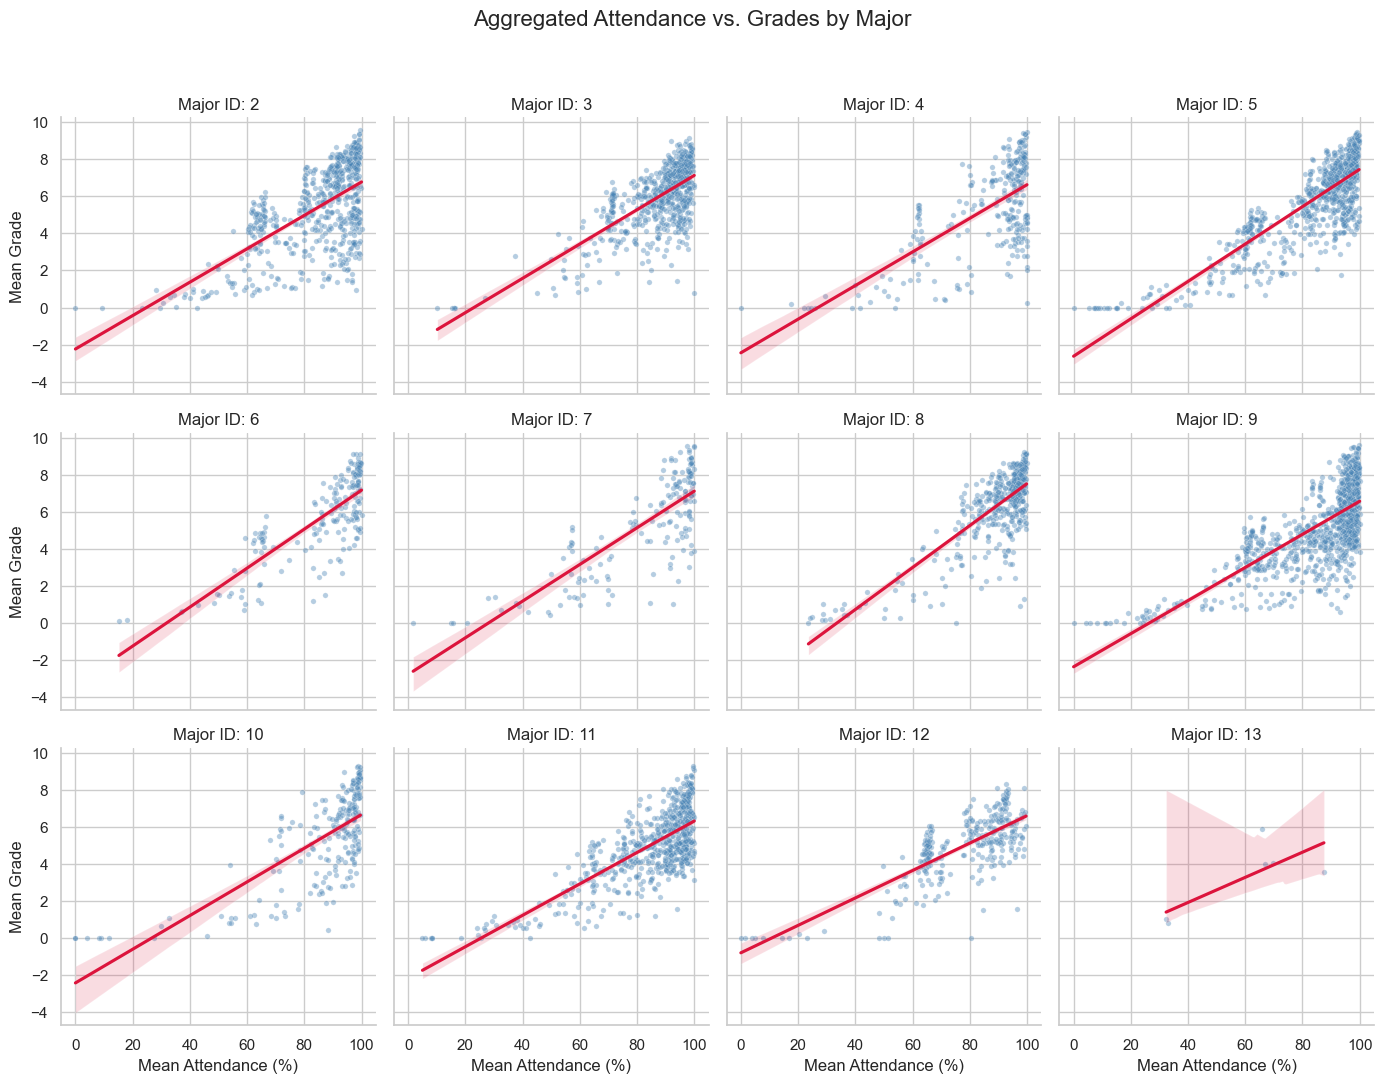

In [6]:
# Triggers the student-level averaged scatter plots
plot_attendance_vs_grades(labeled_grade_history)

## 4. Final Processing: Building Cumulative Time Snapshots
Lastly, we transform our granular course-by-course history into time-series snapshots grouped by student and semester. This structured dataframe is the exact format required to feed into our Machine Learning models (like XGBoost).

In [7]:
# Transform the dataset into chronological feature-engineered slices
student_progress_snapshots = build_progress_snapshots(labeled_grade_history)

print(f"\nFinal Snapshot dataset shape: {student_progress_snapshots.shape}")
print("Features ready for Machine Learning optimization:")
student_progress_snapshots.head()

Building progress snapshots for model processing...

Final Snapshot dataset shape: (25646, 8)
Features ready for Machine Learning optimization:


,semestre_actual,promedio_calificacion_final,promedio_asistencia_final,materias_cursadas,materias_reprobadas,periodos_verano_cursados,std_calificacion_final,resultado_final
0,1,7.540000,63.000000,5,0,1,0.991161,1
1,2,7.420000,70.100000,10,0,1,0.967264,1
2,3,6.730000,80.600000,20,3,1,1.635879,1
3,4,6.576923,83.615385,26,5,1,2.007737,1
4,5,6.858065,85.774194,31,5,1,1.981816,1
